IMPORTING LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

LOADING DATASETS


In [2]:
file_path= 'C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Tourism-Resource-Management-Data-Analysis/Datasets/tourism_resource_dataset.csv'
df= pd.read_csv(file_path)

# Display the first few rows of the datasets
df.head()

,timestamp,location_id,visitor_count,resource_usage_rate,temperature,air_quality_index,noise_level,season,peak_hour_flag,visitor_satisfaction,sensor_noise_flag,resource_prediction,resource_allocation,t_sne_dim1,t_sne_dim2
0,2024-12-01 00:00:00,LOC_003,808,0.907638,19.368864,127,51.506727,summer,0,5.502615,1,0.857819,high,-4.576337,0.582736
1,2024-12-01 01:00:00,LOC_001,948,0.974266,17.404945,37,55.901717,autumn,0,4.736401,0,0.961133,high,-28.314085,20.022820
2,2024-12-01 02:00:00,LOC_003,292,0.321912,16.366819,113,68.533024,winter,1,2.522827,0,0.306956,low,1.329948,5.881103
3,2024-12-01 03:00:00,LOC_003,592,0.811889,20.266316,52,85.301039,autumn,1,2.687745,1,0.701945,medium,-11.921675,20.376535
4,2024-12-01 04:00:00,LOC_001,89,0.936667,15.922471,145,52.258779,summer,1,1.094965,1,0.512834,medium,-6.068825,-4.793058


DATA PREPROCESSING


In [3]:
# Checking for missing values
missing_values= df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [4]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display data types
df.dtypes

timestamp               datetime64[ns]
location_id                     object
visitor_count                    int64
resource_usage_rate            float64
temperature                    float64
air_quality_index                int64
noise_level                    float64
season                          object
peak_hour_flag                   int64
visitor_satisfaction           float64
sensor_noise_flag                int64
resource_prediction            float64
resource_allocation             object
t_sne_dim1                     float64
t_sne_dim2                     float64
dtype: object

EXPLORATORY DATA ANALYSIS (EDA)


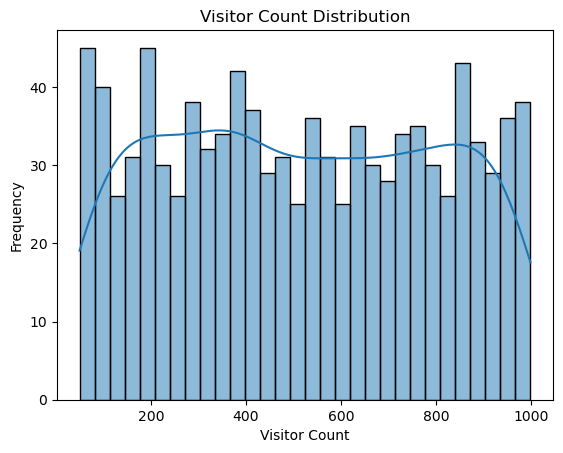

In [5]:
# Visitor count distribution
sns.histplot(df['visitor_count'], bins=30, kde= True)
plt.title('Visitor Count Distribution')
plt.xlabel('Visitor Count')
plt.ylabel('Frequency')
plt.show()

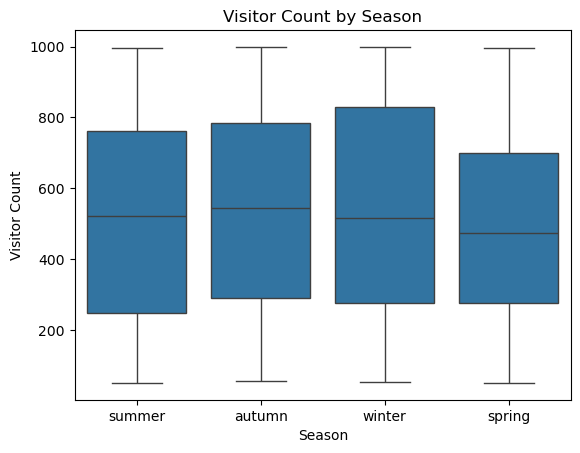

In [7]:
# Visitor count by season
sns.boxplot(x='season', y='visitor_count', data=df)
plt.title('Visitor Count by Season')
plt.xlabel('Season')
plt.ylabel('Visitor Count')
plt.show()

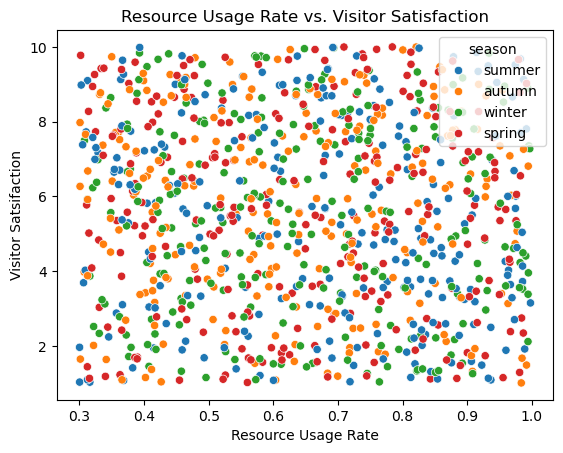

In [8]:
# Resource usage rate vs visitor satisfaction
sns.scatterplot(x='resource_usage_rate', y='visitor_satisfaction', hue='season', data=df)
plt.title('Resource Usage Rate vs. Visitor Satisfaction')
plt.xlabel('Resource Usage Rate')
plt.ylabel('Visitor Satsifaction')
plt.show()

CORRELATION ANALYSIS


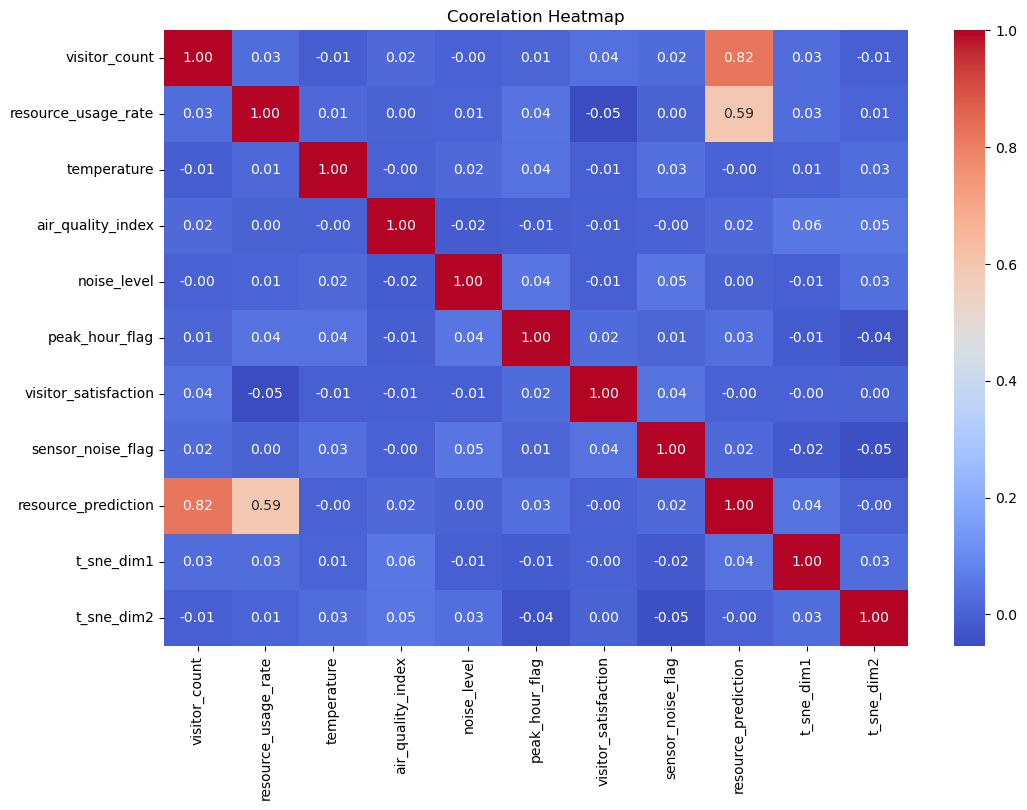

In [9]:
# Select Numeric Columns
numeric_df= df.select_dtypes(include=[np.number])

# Correlation Matrix
corr_matrix= numeric_df.corr()

# Plot Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Coorelation Heatmap')
plt.show()

PREDICTIVE MODELING


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Features and target
X= numeric_df.drop(columns=['resource_prediction'])
y= numeric_df['resource_prediction']

# Train-test split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model= RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred= model.predict(X_test)

# Evaluate Model
mse= mean_squared_error(y_test, y_pred)
rmse= np.sqrt(mse)
rmse

0.012778005319308639

PROJECT END
